In [1]:
%pip install numpy gymnasium matplotlib

Note: you may need to restart the kernel to use updated packages.


# Social layer implementation

In this experiment we show the registering approach for communication and control with existing models. It shows how to turn a simple agent social by adding the three levels of social modulation. First, we start by creating the standard RL agent and environment.

In [22]:
import numpy as np, random, math
from collections import defaultdict
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

class MazeEnvWithFire(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 10}

    def __init__(
        self,
        grid,
        start=(0, 0),
        goal=(0, 0),
        fire_cells=None,
        step_cost=-0.01,
        wall_cost=-0.05,
        goal_reward=1.0,
        max_steps=200,
        render_mode=None,
    ):
        super().__init__()
        self.grid = np.array(grid, dtype=np.int8)  # 0 free, 1 wall
        self.H, self.W = self.grid.shape
        self.start = tuple(start)
        self.goal = tuple(goal)
        self.fire_cells = set(fire_cells or [])
        self.step_cost = float(step_cost)
        self.wall_cost = float(wall_cost)
        self.goal_reward = float(goal_reward)
        self.max_steps = int(max_steps)
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(4)

        agent_obs_space = spaces.Discrete(self.H * self.W)
        fire_space = spaces.Discrete(2)

        self.observation_space = spaces.Dict({"agent_obs": agent_obs_space, "fire": fire_space})

        self._moves = {
            0: (-1, 0),  # up
            1: (0, 1),   # right
            2: (1, 0),   # down
            3: (0, -1),  # left
        }

        self.pos = None
        self.t = 0
        self.last_trajectory = []

    def _agent_obs(self):
        r, c = self.pos
        return r * self.W + c

    def _fire_obs(self):
        return int(self.pos in self.fire_cells)

    def _obs(self):
        return {"agent_obs": self._agent_obs(), "fire": self._fire_obs()}

    def _in_bounds(self, r, c):
        return 0 <= r < self.H and 0 <= c < self.W

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.pos = self.start
        self.t = 0
        obs = self._obs()
        info = {}
        self.last_trajectory = []
        if self.render_mode == "human":
            self.render()
        return obs, info

    def step(self, action):
        self.t += 1
        r, c = self.pos
        dr, dc = self._moves[int(action)]
        nr, nc = r + dr, c + dc

        reward = self.step_cost

        if (not self._in_bounds(nr, nc)) or self.grid[nr, nc] == 1:
            nr, nc = r, c
            reward += self.wall_cost

        self.pos = (nr, nc)

        terminated = (self.pos == self.goal)
        if terminated:
            reward += self.goal_reward

        truncated = (self.t >= self.max_steps)

        obs = self._obs()
        info = {'pos': self.pos}
        self.last_trajectory.append(self.pos)

        if self.render_mode == "human":
            self.render()

        return obs, reward, terminated, truncated, info

    def render(self):
        rA, cA = self.pos
        out = []
        for r in range(self.H):
            row = []
            for c in range(self.W):
                if (r, c) == (rA, cA):
                    row.append("A")
                elif (r, c) == self.start:
                    row.append("S")
                elif (r, c) == self.goal:
                    row.append("G")
                elif (r, c) in self.fire_cells:
                    row.append("F")
                else:
                    row.append("#" if self.grid[r, c] == 1 else ".")
            out.append("".join(row))
        print("\n".join(out))
        print()

def draw_maze_image(grid, fire_cells=None, start=None, goal=None, ax=None, trajectory=None):
    grid_arr = np.array(grid, dtype=np.int8)
    h, w = grid_arr.shape
    fire_cells = set(fire_cells or [])
    img = np.ones((h, w, 3), dtype=np.float32)
    wall_mask = grid_arr == 1
    img[wall_mask] = np.array([0.6, 0.6, 0.6], dtype=np.float32)
    for r, c in fire_cells:
        if 0 <= r < h and 0 <= c < w:
            img[r, c] = np.array([1.0, 0.9, 0.2], dtype=np.float32)
    if start is not None:
        r, c = start
        if 0 <= r < h and 0 <= c < w:
            img[r, c] = np.array([0.2, 0.7, 0.2], dtype=np.float32)
    if goal is not None:
        r, c = goal
        if 0 <= r < h and 0 <= c < w:
            img[r, c] = np.array([0.2, 0.2, 0.8], dtype=np.float32)
    if ax is None:
        _, ax = plt.subplots(figsize=(w * 0.5, h * 0.5))
    ax.imshow(img, interpolation="nearest")
    if trajectory is not None and len(trajectory) > 0:
        traj_r, traj_c = zip(*trajectory)
        ax.plot(traj_c, traj_r, color='red', linewidth=2, marker='o')
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

class QLearningAgent:
    def __init__(self, n_actions, alpha=0.2, gamma=0.99, eps_start=1.0, eps_end=0.05, eps_decay=0.999):
        self.Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float32))
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay

    def act(self, obs):
        if random.random() < self.eps:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.Q[obs]))

    def greedy_act(self, obs):
        return int(np.argmax(self.Q[obs]))

    def update(self, obs, action, reward, next_obs, done):
        q = self.Q[obs][action]
        next_max = 0.0 if done else float(np.max(self.Q[next_obs]))
        target = reward + self.gamma * next_max
        self.Q[obs][action] = q + self.alpha * (target - q)

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


Now we import the main components of the architecture. The general approach is that the user implements the driver, sensory interface, and different skills that will be controlled by the ToM and the Scripts Manager. The ToM operates in a space of abstract action primitives and it is a job of the skill to implement them through the IntentPolicy (I would want to keep the intent primitives minimal)

In [17]:
from architecture_core.core.blackboard import Blackboard
from architecture_core.core.registry import SkillRegistry, SkillEntry
from architecture_core.core.executive import Executive
from architecture_core.core.types import SkillRequest, SkillUpdate, PerceptBundle, NormativeConstraints
from architecture_core.core.status import Status
from architecture_core.skills.base import Skill
from architecture_core.cognition.tom.intent_policy import IntentPolicy

The sensors and driver are trivial, yet necessary.

In [ ]:
class GymDriver:
    def __init__(self, env: MazeEnvWithFire):
        self.env = env

    def reset(self, seed=None):
        return self.env.reset(seed=seed)

    def step(self, action: int):
        return self.env.step(int(action))


In [ ]:
class GymSensors:
    def __init__(self, env: MazeEnvWithFire):
        self.env = env

    def read(self):
        pos = self.env.pos
        fire = int(pos in self.env.fire_cells)
        fire_ahead = {}
        r, c = pos
        for a, (dr, dc) in self.env._moves.items():
            nr, nc = r + dr, c + dc
            if (not self.env._in_bounds(nr, nc)) or self.env.grid[nr, nc] == 1:
                nr, nc = r, c
            fire_ahead[int(a)] = int((nr, nc) in self.env.fire_cells)
        return {
            "pos": pos,
            "agent_obs": self.env._agent_obs(),
            "fire": fire,
            "fire_ahead": fire_ahead,
        }

This is not part of the architecture right now, but the idea is to make it an abstract class so the user has a contract to satisfy.

In [8]:
class MazePerception:
    def __init__(self, sensors: GymSensors):
        self.sensors = sensors

    def tick(self, t: float) -> PerceptBundle:
        raw = self.sensors.read()
        social = {"hazards": {"fire": raw["fire"], "fire_ahead": raw["fire_ahead"]}}
        attention = {"primary": "goal"}  # placeholder
        return PerceptBundle(t=t, world=raw, social=social, attention=attention)

This is necessary because the generic version of these modules are not implemented yet.

In [9]:
class FixedScriptManager:
    def select(self, pb: PerceptBundle, active: SkillRequest | None) -> SkillRequest:
        return SkillRequest(skill="navigate_rl", goal={"goal": "reach_goal"})

class FireNormEngine:
    def evaluate(self, pb: PerceptBundle, candidate: SkillRequest) -> NormativeConstraints:
        out = NormativeConstraints()
        fire_ahead = pb.world.get("fire_ahead", {})
        forbidden = {a for a, is_fire in fire_ahead.items() if int(is_fire) == 1}
        out.hard["forbidden_actions"] = forbidden  # hard constraint: never step into fire
        return out

class FireToMModulator:
    def modulate(self, pb: PerceptBundle, req: SkillRequest) -> SkillUpdate:
        fire = pb.world.get("fire", 0)
        fire_ahead = pb.world.get("fire_ahead", {})
        if fire == 1 or any(v == 1 for v in fire_ahead.values()):
            return SkillUpdate(intent="avoid", debug="ToM: hazard detected")
        return SkillUpdate(intent="approach", debug="ToM: proceed")

This is the proper implementation the user will have to do to adapt their controller to the architecture.

In [10]:
class RLMazeIntentPolicy(IntentPolicy):
    def approach(self, pb: PerceptBundle, req: SkillRequest, base: SkillUpdate) -> SkillUpdate:
        base.constraints.setdefault("forbidden_actions", set())
        base.params.setdefault("mode", "normal")
        return base

    def avoid(self, pb: PerceptBundle, req: SkillRequest, base: SkillUpdate) -> SkillUpdate:
        fire_ahead = pb.world.get("fire_ahead", {})
        forbidden = {a for a, is_fire in fire_ahead.items() if int(is_fire) == 1}
        base.constraints["forbidden_actions"] = forbidden
        base.params["mode"] = "avoid"
        return base

    def yield_(self, pb: PerceptBundle, req: SkillRequest, base: SkillUpdate) -> SkillUpdate:
        base.params["pause"] = True
        base.params["mode"] = "yield"
        return base

    def wait(self, pb: PerceptBundle, req: SkillRequest, base: SkillUpdate) -> SkillUpdate:
        base.params["pause"] = True
        base.params["mode"] = "wait"
        return base

In [18]:
class RLMazeSkill(Skill):
    name = "navigate_rl"

    def __init__(self, driver: GymDriver, agent: QLearningAgent, max_steps: int):
        self.driver = driver
        self.agent = agent
        self.max_steps = max_steps
        self.started = False
        self.steps = 0
        self.trajectory = []

    def start(self, req: SkillRequest) -> None:
        self.started = True
        self.steps = 0
        self.trajectory = []

    def tick(self, pb: PerceptBundle, update: SkillUpdate) -> Status:
        if not self.started:
            # executive should call start; defensive auto-start
            self.start(SkillRequest(skill=self.name))

        # record
        self.trajectory.append(pb.world["pos"])

        if update.params.get("pause", False):
            return "RUNNING"

        obs_int = pb.world["agent_obs"]

        # merge hard constraints from norms into update (executive will do this later; we do it here too defensively)
        forbidden = set(update.constraints.get("forbidden_actions", set()))

        # propose
        a = self.agent.greedy_act(obs_int)

        # shield: if forbidden, choose best allowed alternative
        if a in forbidden:
            qvals = self.agent.Q[obs_int]
            candidates = sorted(range(self.agent.n_actions), key=lambda i: float(qvals[i]), reverse=True)
            a_safe = None
            for cand in candidates:
                if cand not in forbidden:
                    a_safe = cand
                    break
            if a_safe is None:
                return "RUNNING"
            a = a_safe

        obs, reward, terminated, truncated, info = self.driver.step(a)

        self.steps += 1
        if terminated:
            return "SUCCESS"
        if truncated or self.steps >= self.max_steps:
            return "TIMEOUT"
        return "RUNNING"

    def stop(self, reason: str = "") -> None:
        self.started = False

This will also be part of the architecture

In [19]:
class NoopSafetyShield:
    def apply(self, pb: PerceptBundle, req: SkillRequest, update: SkillUpdate, norms: NormativeConstraints) -> SkillUpdate:
        # Merge hard forbidden_actions into update constraints (hard enforcement)
        hard_forbidden = norms.hard.get("forbidden_actions")
        if hard_forbidden is not None:
            # merge if both exist
            cur = set(update.constraints.get("forbidden_actions", set()))
            cur |= set(hard_forbidden)
            update.constraints["forbidden_actions"] = cur
        return update

Now, the executive is the main run-time that manages the control loop. This patched version was necessary because the Executive is not completely implemented.

In [20]:
# Executive in scaffold doesn't call start on skill switch; patch by subclassing for the notebook
class ExecutivePatched(Executive):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._last_req_key = None
        self._started_skill_name = None

    def tick(self, t: float) -> None:
        pb = self.bb.percept
        if pb is None:
            return

        # deliberation (copied behavior)
        if (t - self._last_delib_t) >= self._delib_period:
            candidate = self.scripts.select(pb, self.bb.active_req)
            norms_out = self.norms.evaluate(pb, candidate)
            if norms_out.veto is not None:
                self.bb.active_req = None
            else:
                self.bb.active_req = candidate
                self.bb.norms = norms_out
            self._last_delib_t = t

        if self.bb.active_req is None:
            return

        entry = self.registry.get(self.bb.active_req.skill)

        # Start skill when request changes
        req_key = (self.bb.active_req.skill, tuple(sorted(self.bb.active_req.goal.items())))
        if req_key != self._last_req_key:
            entry.skill.stop("switch")
            entry.skill.start(self.bb.active_req)
            self._last_req_key = req_key

        # ToM intent
        update = self.tom.modulate(pb, self.bb.active_req)

        # IntentPolicy compilation
        if update.intent == "approach":
            compiled = entry.policy.approach(pb, self.bb.active_req, update)
        elif update.intent == "avoid":
            compiled = entry.policy.avoid(pb, self.bb.active_req, update)
        elif update.intent == "yield":
            compiled = entry.policy.yield_(pb, self.bb.active_req, update)
        elif update.intent == "wait":
            compiled = entry.policy.wait(pb, self.bb.active_req, update)
        else:
            compiled = update

        # Safety shield
        compiled = self.shield.apply(pb, self.bb.active_req, compiled, self.bb.norms)

        status = entry.skill.tick(pb, compiled)

        if status in ("SUCCESS", "FAILURE", "TIMEOUT", "PREEMPTED"):
            entry.skill.stop(status)
            self.bb.active_req = None

Now we do a side-by-side comparison

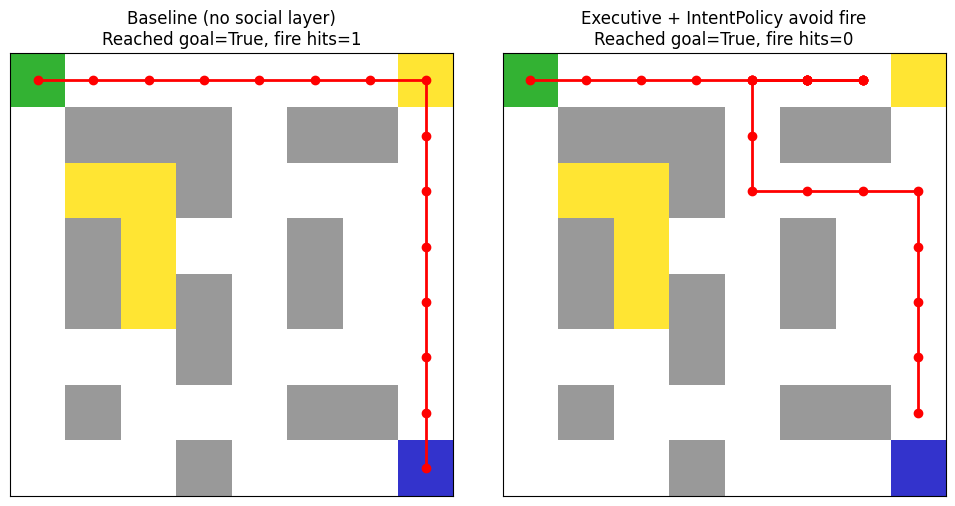

Baseline: reached goal? True fire hits: 1 steps: 15
Social  : reached goal? True fire hits: 0 steps: 30


In [ ]:
# ---- Build an example maze and train the RL agent (ignores fire during training) ----
grid = [
    [0,0,0,0,0,0,0,0],
    [0,1,1,1,0,1,1,0],
    [0,0,0,1,0,0,0,0],
    [0,1,0,0,0,1,0,0],
    [0,1,0,1,0,1,0,0],
    [0,0,0,1,0,0,0,0],
    [0,1,0,0,0,1,1,0],
    [0,0,0,1,0,0,0,0],
]
start = (0,0)
goal = (7,7)

# Put fire near a tempting wall-hugging corridor
fire_cells = [(2,1),(2,2),(3,2),(4,2),(0,7)]

train_env = MazeEnvWithFire(grid, start=start, goal=goal, fire_cells=fire_cells, max_steps=200, render_mode=None)
agent = QLearningAgent(n_actions=4, alpha=0.2, gamma=0.99, eps_start=1.0, eps_end=0.05, eps_decay=0.999)

def train(agent, env, episodes=2000, seed=0):
    random.seed(seed); np.random.seed(seed)
    for ep in range(episodes):
        obs, _ = env.reset(seed=seed+ep)
        done = False
        while not done:
            s = obs["agent_obs"]  # agent ignores obs["fire"]
            a = agent.act(s)
            next_obs, r, term, trunc, _ = env.step(a)
            done = term or trunc
            agent.update(s, a, r, next_obs["agent_obs"], done)
            obs = next_obs
        agent.decay_eps()

train(agent, train_env, episodes=2500)

# ---- Baseline rollout (greedy RL agent, no social layer) ----
def rollout_baseline(agent, env, max_steps=200, seed=123):
    obs, _ = env.reset(seed=seed)
    traj = [env.pos]
    fire_hits = 0
    for _ in range(max_steps):
        s = obs["agent_obs"]
        a = agent.greedy_act(s)
        obs, r, term, trunc, info = env.step(a)
        traj.append(env.pos)
        if obs["fire"] == 1:
            fire_hits += 1
        if term or trunc:
            break
    return traj, fire_hits, env.pos == env.goal

baseline_env = MazeEnvWithFire(grid, start=start, goal=goal, fire_cells=fire_cells, max_steps=200, render_mode=None)
traj_base, fire_hits_base, reached_base = rollout_baseline(agent, baseline_env)

# ---- Social-layer rollout via Executive ----
social_env = MazeEnvWithFire(grid, start=start, goal=goal, fire_cells=fire_cells, max_steps=200, render_mode=None)
driver = GymDriver(social_env)
sensors = GymSensors(social_env)
perception = MazePerception(sensors)

# Reset env
driver.reset(seed=123)

bb = Blackboard() # The blackboard pattern is a very useful way to manage state and communication between components in an executive architecture. It allows for a clean separation of concerns and makes it easier to integrate different modules like perception, decision-making, and action execution.
registry = SkillRegistry()
skill = RLMazeSkill(driver=driver, agent=agent, max_steps=200)
policy = RLMazeIntentPolicy()
registry.register(SkillEntry(skill=skill, policy=policy))

executive = ExecutivePatched(
    bb=bb,
    registry=registry,
    scripts=FixedScriptManager(),
    norms=FireNormEngine(),      # hard "never step into fire"
    tom=FireToMModulator(),      # outputs avoid/approach
    shield=NoopSafetyShield(),   # merges hard constraints into update
    deliberation_hz=5.0,
)

t = 0.0
dt = 0.1
max_ticks = 4000
for _ in range(max_ticks):
    bb.percept = perception.tick(t)
    executive.tick(t)
    t += dt
    # stop once env is done
    if social_env.pos == social_env.goal:
        break
    if social_env.t >= social_env.max_steps:
        break

traj_social = skill.trajectory
fire_hits_social = sum(int(p in social_env.fire_cells) for p in traj_social)
reached_social = (social_env.pos == social_env.goal)

# ---- Plot both trajectories ----
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
draw_maze_image(grid, fire_cells=fire_cells, start=start, goal=goal, ax=axes[0], trajectory=traj_base)
axes[0].set_title(f"Baseline (no social layer)\nReached goal={reached_base}, fire hits={fire_hits_base}")
draw_maze_image(grid, fire_cells=fire_cells, start=start, goal=goal, ax=axes[1], trajectory=traj_social)
axes[1].set_title(f"Executive + IntentPolicy avoid fire\nReached goal={reached_social}, fire hits={fire_hits_social}")
plt.tight_layout()
plt.show()

print("Baseline: reached goal?", reached_base, "fire hits:", fire_hits_base, "steps:", len(traj_base))
print("Social  : reached goal?", reached_social, "fire hits:", fire_hits_social, "steps:", len(traj_social))
